In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from typing import Tuple, List
import os
import re

In [6]:
def parse_filenames(df: pd.DataFrame) -> pd.DataFrame:
    """Processes a DataFrame to extract sample name, cleaning method, proportion, and mix method.
    
    It reads from a column 'Unnamed: 0', creates 'sample_name',
    'clean_method', 'proportion', and 'mix_method' columns, and then drops 
    the original column.

    Args:
        df: The input pandas DataFrame.

    Returns:
        A new DataFrame with the processed columns.
    """
    
    # Work on a copy to avoid side effects and SettingWithCopyWarning
    df_copy = df.copy()
    
    # The name of the column containing the filenames
    filename_col = 'Unnamed: 0'

    def parse_filename(filename: str) -> Tuple[str, str, str, str]:
        """Parses a filename string to extract sample name, cleaning method, proportion, and mix method.

        Args:
            filename: The filename string to parse.

        Returns:
            A tuple containing the sample name, clean method, proportion, and mix method.
        """
        
        # Clean the filename by removing the extension and any whitespace
        clean_name = filename.replace('.fcs', '').strip()
        
        sample_name_base = ''
        clean_method = ''
        
        # Logic to handle different filename formats to extract clean_method
        if clean_name.startswith('flowmop_'):
            clean_method = 'flowmop'
            sample_name_base = clean_name.removeprefix('flowmop_')
        elif clean_name.endswith('_flowcut'):
            clean_method = 'flowcut'
            sample_name_base = clean_name.removesuffix('_flowcut')
        elif clean_name.endswith('_peacoqc'):
            clean_method = 'peacoqc'
            sample_name_base = clean_name.removesuffix('_peacoqc')
        else:
            sample_name_base = clean_name

        # Extract mix_method and proportion from the sample_name
        parts = sample_name_base.split('_')
        
        mix_method = ''
        proportion = ''
        sample_name = ''

        if len(parts) > 2:
            mix_method = parts[-1]
            proportion_str = parts[-2]
            sample_name = '_'.join(parts[:-2])

            # Use regex to split the proportion string into 2-digit chunks
            proportions_list = re.findall(r'(\d{2})', proportion_str)
            proportion = ','.join(proportions_list)
        else:
            sample_name = sample_name_base
            
        return sample_name, clean_method, proportion, mix_method

    # Apply the parsing function to the column to create new columns
    df_copy[['sample_name', 'clean_method', 'proportion', 'mix_method']] = df_copy[filename_col].apply(
        lambda name: pd.Series(parse_filename(name))
    )
    
    # Drop the original 'Unnamed: 0' column
    df_processed = df_copy.drop(columns=[filename_col])
    
    return df_processed

In [41]:
synth_dir = r"C:\Users\Tony\Documents\github_remotes\FlowMOP\figs\fig_2_data\fig_2_analysis"
csvs = [f for f in os.listdir(synth_dir) if f.endswith('.csv')]
time_data = [pd.read_csv(synth_dir + "\\" + csv).iloc[:22] for csv in csvs if 'timegates' in csv]
for i, time in enumerate(time_data): 
    time_data[i] = time_data[i][~time_data[i]['Unnamed: 0'].str.contains('Mean', na=False)]
    time_data[i] = time_data[i][~time_data[i]['Unnamed: 0'].str.contains('SD', na=False)]

In [42]:
for i, time in enumerate(time_data): 
    time_data[i] = parse_filenames(time).sort_values(by=['sample_name',"mix_method"]).reset_index(drop=True)

overall_counts = time_data[1]["Count"]

# Some specific reformatting
time_data[1]["Count"] = overall_counts * time_data[1]["passedtime subset | Freq. of Parent (%)"]/100
time_data[1].drop(columns=["passedtime subset | Freq. of Parent (%)","Unnamed: 6"], inplace=True)
time_data[0].drop(columns=["Unnamed: 5"], inplace=True)
time_data[2].drop(columns=["Unnamed: 5"], inplace=True)

In [43]:
def rename_freq_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Renames columns containing 'Freq. of Parent' to a simplified 'sample_n' format.
    The renaming is sequential.

    For example, '1 | Freq. of Parent (%)' becomes 'sample_1' and 
    'passedtime subset | Freq. of Parent (%)' also becomes 'sample_1'.

    Args:
        df: The pandas DataFrame with columns to be renamed.

    Returns:
        The DataFrame with renamed columns.
    """
    df_copy = df.copy()
    
    rename_map = {}
    sample_counter = 1
    
    # Find all columns that need renaming, maintaining their order.
    cols_to_rename = [col for col in df_copy.columns if 'Freq. of Parent' in col]

    # Generate the new names sequentially.
    for col_name in cols_to_rename:
        rename_map[col_name] = f'sample_{sample_counter}'
        sample_counter += 1
            
    df_copy.rename(columns=rename_map, inplace=True)
    return df_copy

# This loop assumes 'time_data' is a list of DataFrames.
# Also adding overall counts
for i in range(len(time_data)):
    time_data[i] = rename_freq_columns(time_data[i])
    time_data[i]["original_counts"] = overall_counts

In [44]:
for i, time in enumerate(time_data): 
    time_data[i]["passed_time"] = time_data[i]["Count"]/overall_counts

In [45]:
def add_target_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds 'target_1', 'target_2', and 'target_3' columns based on the 'proportion' column.

    The mapping from 'proportion' to targets is predefined based on the experimental setup.

    Args:
        df: The pandas DataFrame with a 'proportion' column.

    Returns:
        The DataFrame with the new target columns.
    """
    df_copy = df.copy()

    proportion_map = {
        '20,80': (0, 80, 0),
        '65,35': (65, 0, 0),
        '40,40,20': (40, 40, 0),
        '50,50': (50, 50, 0),
        '20,20,60': (0, 0, 60),
        '80,20': (80, 0, 0),
        '': (0, 0, 0)  # Handles cases with no specified proportion.
    }

    proportion_map_original = {
        '20,80': (20, 80, 0),
        '65,35': (65, 35, 0),
        '40,40,20': (40, 40, 20),
        '50,50': (50, 50, 0),
        '20,20,60': (20, 20, 60),
        '80,20': (80, 20, 0),
        '': (0, 0, 0)  # Handles cases with no specified proportion.
    }

    def map_proportions(proportion_str: str) -> tuple:
        """Looks up the proportion string in the map."""
        return proportion_map.get(proportion_str, (None, None, None))

    def map_proportions_original(proportion_str: str) -> tuple:
        """Looks up the proportion string in the map."""
        return proportion_map_original.get(proportion_str, (None, None, None))

    # Apply the mapping to the 'proportion' column.
    targets = df_copy['proportion'].apply(map_proportions)
    original_targets = df_copy['proportion'].apply(map_proportions_original)
    
    # Create the new columns from the list of tuples.
    df_copy[['target_1', 'target_2', 'target_3']] = pd.DataFrame(targets.tolist(), index=df_copy.index)
    df_copy[['original_1', 'original_2', 'original_3']] = pd.DataFrame(original_targets.tolist(), index=df_copy.index)

    return df_copy

alltime_data = pd.concat(time_data)
alltime_data = add_target_columns(alltime_data)

# You can inspect one of the DataFrames to verify the changes.
alltime_data.head()

,Count,sample_1,sample_2,sample_3,sample_name,clean_method,proportion,mix_method,original_counts,passed_time,target_1,target_2,target_3,original_1,original_2,original_3
0,645000.0,19.5,80.5,0.0,A051,flowcut,"20,80",bimix,658000.0,0.980243,0,80,0,20,80,0
1,653000.0,17.1,82.9,0.0,A051,flowcut,"20,80",segment,704000.0,0.927557,0,80,0,20,80,0
2,393625.0,49.8,50.2,0.0,A0513,flowcut,"40,40,20",trimix,622000.0,0.632838,40,40,0,40,40,20
3,312418.0,64.6,35.4,0.0,A053,flowcut,"65,35",bimix,322418.0,0.968984,65,0,0,65,35,0
4,365329.0,63.6,36.4,0.0,A053,flowcut,"65,35",segment,382595.0,0.954871,65,0,0,65,35,0


In [46]:
# Weird flowjo outputs mean need to int and float stuff
alltime_data["Count"] = alltime_data["Count"].astype(int)

# Define the columns that need to be cleaned and converted
sample_cols = ['sample_1', 'sample_2', 'sample_3']
other_numeric_cols = ['Count', 'original_counts', 'target_1', 'target_2', 'target_3']

# Clean and convert the 'sample' columns
for col in sample_cols:
    # Replace the malformed 'E?' with 'E-' and convert to a numeric type
    alltime_data[col] = pd.to_numeric(
        alltime_data[col].astype(str).str.replace('E?', 'E-', regex=False),
        errors='coerce'
    )


In [47]:
def correct_remove(sample_count, target_count, original_count):
    if target_count == 0: 
        return original_count - sample_count
    else: 
        return 0

def correct_keep(sample_count, target_count):
    if target_count == 0: 
        return 0
    else: 
        return min(sample_count, target_count)
    
def incorrect_remove(sample_count, target_count):
    if target_count == 0: 
        return 0
    elif sample_count < target_count:
        return (target_count - sample_count)
    else: 
        return 0

def incorrect_keep(sample_count, target_count):
    if target_count == 0: 
        return sample_count
    elif sample_count > target_count:
        return (sample_count - target_count)
    else: 
        return 0

In [48]:
for k in range(1,4):
    alltime_data[f"sample_{k}_count"] = alltime_data[f"sample_{k}"]/100 * alltime_data["Count"]
    alltime_data[f"target_{k}_count"] = alltime_data[f"target_{k}"]/100 * alltime_data["original_counts"]
    alltime_data[f"original_{k}_count"] = alltime_data[f"original_{k}"]/100 * alltime_data["original_counts"]
    alltime_data[f"correct_remove_{k}"] = alltime_data.apply(lambda row: correct_remove(row[f"sample_{k}_count"], row[f"target_{k}_count"], row[f"original_{k}_count"]), axis=1)
    alltime_data[f"correct_keep_{k}"] = alltime_data.apply(lambda row: correct_keep(row[f"sample_{k}_count"], row[f"target_{k}_count"]), axis=1)
    alltime_data[f"incorrect_remove_{k}"] = alltime_data.apply(lambda row: incorrect_remove(row[f"sample_{k}_count"], row[f"target_{k}_count"]), axis=1)
    alltime_data[f"incorrect_keep_{k}"] = alltime_data.apply(lambda row: incorrect_keep(row[f"sample_{k}_count"], row[f"target_{k}_count"]), axis=1)

In [49]:
alltime_data["target_count_overall"] = sum(
    [alltime_data["target_1_count"], alltime_data["target_2_count"], alltime_data["target_3_count"]])
alltime_data["sample_count_overall"] = sum(
    [alltime_data["sample_1_count"], alltime_data["sample_2_count"], alltime_data["sample_3_count"]])

alltime_data["correct_keep_overall"] = sum(
    [alltime_data["correct_keep_1"], alltime_data["correct_keep_2"], 
     alltime_data["correct_keep_3"]]
     )/alltime_data["Count"] # Counts to see how many of the ones we have here are correct
alltime_data["incorrect_keep_overall"] = sum(
    [alltime_data["incorrect_keep_1"], alltime_data["incorrect_keep_2"], 
     alltime_data["incorrect_keep_3"]]
     )/alltime_data["Count"] # Counts to see how many of the ones we have here are incorrect

# Dividing by the difference of the number of cells that we have removed 
alltime_data["correct_remove_overall"] = sum(
    [alltime_data["correct_remove_1"], alltime_data["correct_remove_2"], 
     alltime_data["correct_remove_3"]]
     )/(alltime_data["original_counts"]-alltime_data["Count"]) 

alltime_data["incorrect_remove_overall"] = sum(
    [alltime_data["incorrect_remove_1"], alltime_data["incorrect_remove_2"], 
    alltime_data["incorrect_remove_3"]]
    )/(alltime_data["original_counts"]-alltime_data["Count"])

In [53]:
# Drop the 50:50 ones

# Get the rows where proportion is "50,50"
mask = alltime_data["proportion"] == "50,50"
group5050 = alltime_data[mask].copy()
# Remove those rows from the original dataframe
alltime_data = alltime_data[~mask].reset_index(drop=True)

C:\Users\Tony\AppData\Local\Temp\ipykernel_8448\2505617468.py:113: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


pivoted_df for mix method segment  is  clean_method  flowcut  flowmop  peacoqc
sample_name                            
A051            0.829    1.000      1.0
A053            0.636    1.000      1.0
A31             0.653    1.000      1.0
B051            0.647    0.983      1.0
B053            1.000    1.000      1.0
B31             0.823    1.000      1.0
p_raw is  0.36321746764912244
p_raw is  0.010460878557759666
p_raw is  0.010711607900470682
pivoted_df for mix method bimix  is  clean_method  flowcut  flowmop  peacoqc
sample_name                            
A051            0.805    1.000    0.986
A053            0.646    0.817    0.988
A31             0.661    0.635    0.643
B051            0.656    0.715    0.987
B053            1.000    1.000    0.822
B31             1.000    0.852    0.798
p_raw is  0.627279076012622
p_raw is  0.4620513653701564
p_raw is  0.4797514457923512
pivoted_df for mix method trimix  is  clean_method  flowcut   flowmop  peacoqc
sample_name                

C:\Users\Tony\AppData\Local\Temp\ipykernel_8448\2505617468.py:113: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


pivoted_df for mix method segment  is  clean_method  flowcut  flowmop  peacoqc
sample_name                            
A051            0.171   0.0000      0.0
A053            0.364   0.0000      0.0
A31             0.347   0.0000      0.0
B051            0.353   0.0165      0.0
B053            0.000   0.0000      0.0
B31             0.177   0.0000      0.0
p_raw is  0.36321746764912244
p_raw is  0.01046708526230946
p_raw is  0.010711607900470677
pivoted_df for mix method bimix  is  clean_method  flowcut   flowmop  peacoqc
sample_name                             
A051          0.19500  0.000018   0.0136
A053          0.35400  0.183000   0.0121
A31           0.33900  0.365000   0.3570
B051          0.34400  0.285000   0.0129
B053          0.00000  0.000044   0.1780
B31           0.00038  0.148000   0.2020
p_raw is  0.626474417017971
p_raw is  0.46114246555234545
p_raw is  0.4789491286356774
pivoted_df for mix method trimix  is  clean_method  flowcut   flowmop  peacoqc
sample_name        

C:\Users\Tony\AppData\Local\Temp\ipykernel_8448\2505617468.py:113: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


pivoted_df for mix method segment  is  clean_method   flowcut   flowmop   peacoqc
sample_name                               
A051          0.571314  0.617281  0.352441
A053          0.053776  0.958898  0.453013
A31           0.572000  0.859951  0.493421
B051          0.295879  0.905832  0.650602
B053          0.792453  0.677966  0.322209
B31           0.749700  0.441501  0.711429
p_raw is  0.07456682357356968
p_raw is  0.25883778575109573
p_raw is  0.9519336175295714
pivoted_df for mix method bimix  is  clean_method   flowcut   flowmop   peacoqc
sample_name                               
A051          0.448077  0.617243  0.592143
A053          0.225033  0.781564  0.717246
A31           0.693200  0.150714  0.270308
B051          0.468312  0.781177  0.722809
B053          0.649573  0.671038  0.315049
B31           0.673765  0.527562  0.183929
p_raw is  0.17712805116512487
p_raw is  0.7078000711461232
p_raw is  0.7366298981925472
pivoted_df for mix method trimix  is  clean_method   flowcu

C:\Users\Tony\AppData\Local\Temp\ipykernel_8448\2505617468.py:113: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


pivoted_df for mix method segment  is  clean_method   flowcut   flowmop   peacoqc
sample_name                               
A051          0.428686  0.382719  0.647559
A053          0.946224  0.041102  0.546987
A31           0.428000  0.140049  0.506579
B051          0.704121  0.095001  0.349398
B053          0.207547  0.322034  0.677791
B31           0.250300  0.558499  0.288571
p_raw is  0.07468126159867244
p_raw is  0.25895762206699824
p_raw is  0.951933617529567
pivoted_df for mix method bimix  is  clean_method   flowcut   flowmop   peacoqc
sample_name                               
A051          0.551923  0.382719  0.408698
A053          0.774967  0.218436  0.282645
A31           0.306800  0.849286  0.729692
B051          0.531688  0.218823  0.277301
B053          0.350427  0.328859  0.684951
B31           0.325333  0.472438  0.816071
p_raw is  0.17652300827751413
p_raw is  0.7084340771183608
p_raw is  0.7354767723805773
pivoted_df for mix method trimix  is  clean_method   flowcut

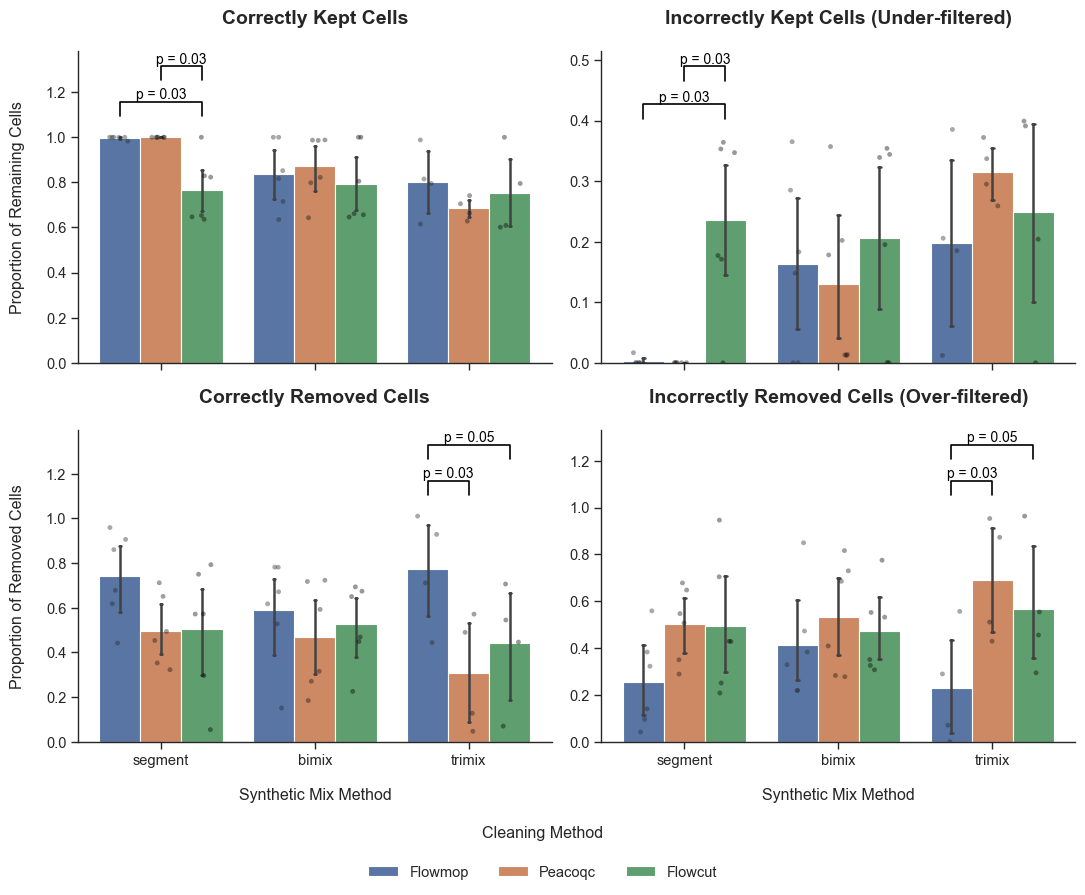

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel
from itertools import combinations

# --- Helper function for formatting p-values ---
def format_p_value(p):
    if p < 0.001:
        return "p < 0.001"
    elif p < 0.01:
        return f"p = {p:.3f}"
    else: # p-values between 0.01 and 0.05
        return f"p = {p:.2f}"

# --- Helper function to add statistical annotations (REVISED for Paired T-test) ---
def add_stat_annotation(ax, data, y_col, mix_methods_order, clean_methods_order):
    """
    Performs paired t-tests with Bonferroni correction and adds significance brackets.
    """
    n_mix = len(mix_methods_order)
    
    # Iterate over each primary group on the x-axis
    for mix_idx, mix_method in enumerate(mix_methods_order):
        
        sub_df = data[data['mix_method'] == mix_method]
        
        if len(sub_df['clean_method'].unique()) < 2:
            continue
            
        # --- Paired T-test Logic ---
        # Pivot the data to align samples by 'sample_name'
        pivoted_df = sub_df.pivot(index='sample_name', columns='clean_method', values=y_col)

        # Get all pairwise combinations of cleaning methods
        comparisons = list(combinations(clean_methods_order, 2))
        m = len(comparisons) # Bonferroni correction factor
        sig_results = []
        for group1, group2 in comparisons:
            # Drop rows with NaNs for the pair to ensure samples are properly paired
            pair_df = pivoted_df[[group1, group2]].dropna()
            
            if len(pair_df) < 2: # Need at least 2 pairs for a t-test
                continue

            # Perform the paired t-test
            stat, p_raw = ttest_rel(pair_df[group1], pair_df[group2])
            # Apply Bonferroni correction
            p_adj = min(p_raw * m, 1.0)
            
            if p_adj < 0.05:
                sig_results.append({'group1': group1, 'group2': group2, 'p-adj': p_adj})

        if not sig_results:
            continue
            
        # --- Drawing Logic ---
        group_max = sub_df[y_col].max()
        y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
        y_offset = y_range * 0.06
        
        current_y = group_max + y_offset * 1.5
        
        for result in sig_results:
            group1, group2 = result['group1'], result['group2']
            p_val = result['p-adj']
            
            clean_idx1 = clean_methods_order.index(group1)
            clean_idx2 = clean_methods_order.index(group2)
            
            bar1 = ax.patches[clean_idx1 * n_mix + mix_idx]
            bar2 = ax.patches[clean_idx2 * n_mix + mix_idx]
            x1, x2 = bar1.get_x() + bar1.get_width() / 2, bar2.get_x() + bar2.get_width() / 2
            
            ax.plot([x1, x1, x2, x2], [current_y, current_y + y_offset, current_y + y_offset, current_y], lw=1.2, c='black')
            ax.text((x1 + x2) / 2, current_y + y_offset, format_p_value(p_val), ha='center', va='bottom', color='black', fontsize=10)
            
            current_y += y_offset * 2.5


# --- Main plotting script ---

alltime_data.reset_index(drop=True, inplace=True)
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

subplot_titles = [
    "Correctly Kept Cells", "Incorrectly Kept Cells (Under-filtered)",
    "Correctly Removed Cells", "Incorrectly Removed Cells (Over-filtered)"
]
y_cols = [
    'correct_keep_overall', 'incorrect_keep_overall',
    'correct_remove_overall', 'incorrect_remove_overall'
]
mix_methods_order = ["segment", "bimix", "trimix"]
clean_methods_order = ["flowmop", "peacoqc", "flowcut"]

label_titles = ["FlowMOP", "PeacoQC", "FlowCut"]

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True)
axes = axes.flatten()

handles, labels = None, None

for i, ax in enumerate(axes):
    y_col = y_cols[i]

    sns.barplot(
        data=alltime_data, x='mix_method', y=y_col, hue='clean_method',
        order=mix_methods_order, hue_order=clean_methods_order, ax=ax,
        errorbar=('ci', 95), capsize=.05, palette='deep'
    )
    sns.stripplot(
        data=alltime_data, x='mix_method', y=y_col, hue='clean_method',
        order=mix_methods_order, hue_order=clean_methods_order, ax=ax,
        dodge=True, color='black', s=3.5, alpha=0.4, jitter=0.2, legend=False
    )
    
    ax.set_title(subplot_titles[i], loc='center', fontsize=14, weight='bold', pad=20)
    
    if i % 2 == 0:
        if 'keep' in y_cols[i].lower():
            ax.set_ylabel("Proportion of Remaining Cells", labelpad=15)
        elif 'remove' in y_cols[i].lower():
            ax.set_ylabel("Proportion of Removed Cells", labelpad=15)
    else:
        ax.set_ylabel("")
        
    if i < 2:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("Synthetic Mix Method", labelpad=15)
        
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
    if ax.get_legend() is not None:
        ax.get_legend().remove()
        
    add_stat_annotation(ax, alltime_data, y_col, mix_methods_order, clean_methods_order)


legend = fig.legend(
    handles, label_titles, title='Cleaning Method\n', bbox_to_anchor=(0.5, 0),
    loc='lower center', ncol=len(labels), frameon=False
)
plt.setp(legend.get_title(), multialignment='center')

sns.despine(fig)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

C:\Users\Tony\AppData\Local\Temp\ipykernel_8448\3526781019.py:49: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\Tony\AppData\Local\Temp\ipykernel_8448\3526781019.py:49: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\Tony\AppData\Local\Temp\ipykernel_8448\3526781019.py:49: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\Tony\AppData\Local\Temp\ipykernel_8448\3526781019.py:49: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


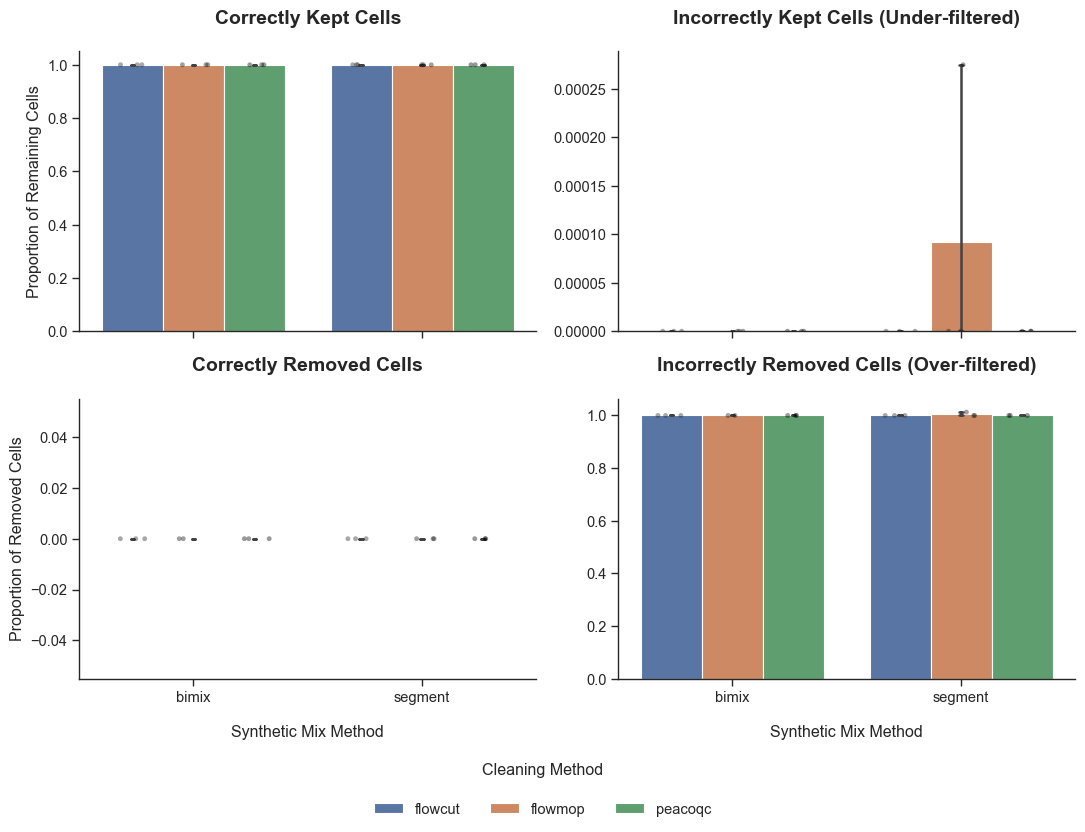

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- FIX: Reset the index to prevent the ValueError ---
group5050.reset_index(drop=True, inplace=True)

# Set the style for a publication-quality look
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# 1. Define subplot titles and the corresponding data columns
subplot_titles = [
    "Correctly Kept Cells", "Incorrectly Kept Cells (Under-filtered)",
    "Correctly Removed Cells", "Incorrectly Removed Cells (Over-filtered)"
]
y_cols = [
    'correct_keep_overall', 'incorrect_keep_overall',
    'correct_remove_overall', 'incorrect_remove_overall'
]
mix_methods_order = sorted(group5050['mix_method'].unique())
clean_methods_order = sorted(group5050['clean_method'].unique())

# 2. Create the 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True)
axes = axes.flatten()

handles, labels = None, None

# 3. Loop through the four metrics and add them to the subplots
for i, ax in enumerate(axes):
    y_col = y_cols[i]

    # Bar plot with error bars
    sns.barplot(
        data=group5050,
        x='mix_method',
        y=y_col,
        hue='clean_method',
        order=mix_methods_order,
        hue_order=clean_methods_order,
        ax=ax,
        errorbar=('ci', 95),
        capsize=.05,
        palette='deep'
    )

    # Overlay individual data points with more jitter
    sns.stripplot(
        data=group5050,
        x='mix_method',
        y=y_col,
        hue='clean_method',
        order=mix_methods_order,
        hue_order=clean_methods_order,
        ax=ax,
        dodge=True,
        color='black',
        s=3.5,
        alpha=0.4,
        jitter=0.2,
        legend=False
    )

    # --- CHANGE: Add padding to subplot titles to move them up ---
    ax.set_title(subplot_titles[i], loc='center', fontsize=14, weight='bold', pad=20)

    # Set new Y-axis labels only for the left column
    if i % 2 == 0:
        if 'keep' in y_cols[i].lower():
            ax.set_ylabel("Proportion of Remaining Cells")
        elif 'remove' in y_cols[i].lower():
            ax.set_ylabel("Proportion of Removed Cells")
    else:
        ax.set_ylabel("")

    if i < 2: # Top row
        ax.set_xlabel("")
    else: # Bottom row
        ax.set_xlabel("Synthetic Mix Method", labelpad=15)

    # Handle the legend
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
    
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# 4. Final layout adjustments
# Add a single, shared legend at the bottom
legend = fig.legend(
    handles, 
    labels, 
    # --- CHANGE: Add newline to title for spacing and center it ---
    title='Cleaning Method\n', 
    bbox_to_anchor=(0.5, 0),
    loc='lower center', 
    ncol=len(labels), 
    frameon=False
)
plt.setp(legend.get_title(), multialignment='center')

# Despine for a cleaner look
sns.despine(fig)

# --- CHANGE: Adjust tight_layout to create more outer margin for legend and suptitle ---
plt.tight_layout(
    rect=[0, 0.08, 1, 0.93] # rect: [left, bottom, right, top]
)

plt.show()